# Feedforward Neural Network
### A Comparative Study Across MNIST, CIFAR-10, and CIFAR-100

---

In [ ]:
# Design a feed-forward neural networks with two hidden layers, one input layer, one output
# layer and one softmax layer. Create the training loop to train your model for 10 epochs. Use the SGD
# optimizer, the cross-entropy loss function for the training purpose and apply the minibatch training
# principle with the batch size of 32. The batch size can be reduced if your machine does not have
# sufficient memory and the learning rate is fixed at 0.01.

# Finally, train your model in the training set,
# evaluate your model in the testing set and calculate the training time. Visualize the predictive
# performance of your method by taking randomly one image and predicting its class. Train and evaluate
# your model using three datasets: MNIST, CIFAR10, CIFAR100 where all of them are available to
# download from the torchvision

## Section 1 — Imports and Setup

In [ ]:
# ============================================
# IMPORTS AND SETUP
# ============================================

import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import time
import random

from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Select device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Using device: cuda
GPU: Tesla T4


## Section 1B — Global Visualization Style

In [ ]:
# ============================================
# GLOBAL VISUALIZATION STYLE
# ============================================

import matplotlib as mpl

PALETTE = {
    "loss":          "#8E1B1B",  # deep classic red
    "accuracy":      "#1F4E79",  # navy blue
    "bar_primary":   "#2E5C6E",  # slate teal
    "bar_secondary": "#8E1B1B",
    "grid":          "#B0B0B0",
    "correct":       "#1B7837",  # forest green
    "incorrect":     "#B2182B",  # crimson
}

plt.rcParams.update({
    # Fonts — classic serif, bold headings
    "font.family":        "serif",
    "font.serif":         ["Georgia", "Times New Roman", "DejaVu Serif"],
    "font.size":          13,

    # Titles & axis labels
    "axes.titlesize":     17,
    "axes.titleweight":   "bold",
    "axes.labelsize":     14,
    "axes.labelweight":   "bold",
    "figure.titlesize":   19,
    "figure.titleweight": "bold",

    # Tick labels
    "xtick.labelsize":    11,
    "ytick.labelsize":    11,

    # Legend
    "legend.fontsize":    12,
    "legend.frameon":     True,
    "legend.framealpha":  0.9,
    "legend.edgecolor":   "#333333",

    # Axes & grid — clean, classic look
    "axes.facecolor":     "#FAFAFA",
    "axes.edgecolor":     "#333333",
    "axes.linewidth":     1.3,
    "grid.color":         PALETTE["grid"],
    "grid.linestyle":     "--",
    "grid.alpha":         0.55,
    "axes.grid":          True,

    # Figure
    "figure.facecolor":   "white",
    "figure.dpi":         110,
    "savefig.dpi":        160,
})

print("Global plot style applied: classic serif theme with bold titles/labels.")


Global plot style applied: classic serif theme with bold titles/labels.


## Section 2 — Hyperparameters

In [ ]:
## Experimental Configuration

# The same main training configuration is used across the three datasets to provide a consistent comparison.
# The batch size is set to 32, the learning rate is fixed at 0.01, and the model is trained for 10 epochs using the SGD optimizer and cross-entropy loss.


In [ ]:
# ============================================
# EXPERIMENTAL CONFIGURATION
# ============================================

BATCH_SIZE = 32
LEARNING_RATE = 0.01
EPOCHS = 10

print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)

Batch size: 32
Learning rate: 0.01
Epochs: 10


## Section 3 — FFNN Model

In [ ]:
# FFNN Architecture

# The feed-forward neural network consists of an input layer, two hidden layers, and an output layer.
# The input image is flattened into a one-dimensional vector before being passed through the fully connected layers.

# The first and second hidden layers use the ReLU activation function. The final layer produces one logit for each class. During training, these logits are directly passed to the cross-entropy loss function.
# During prediction, Softmax is applied to obtain class probabilities.

In [ ]:
# ============================================
# FEED-FORWARD NEURAL NETWORK
# ============================================

class FeedForwardNN(nn.Module):

    def __init__(self, input_size, hidden1_size, hidden2_size, num_classes):
        super(FeedForwardNN, self).__init__()

        self.network = nn.Sequential(
            nn.Flatten(),

            # Hidden Layer 1
            nn.Linear(input_size, hidden1_size),
            nn.ReLU(),

            # Hidden Layer 2
            nn.Linear(hidden1_size, hidden2_size),
            nn.ReLU(),

            # Output Layer
            nn.Linear(hidden2_size, num_classes)
        )

    def forward(self, x):
        return self.network(x)

## Section 4 — Training and Evaluation Functions

In [ ]:
## Training and Evaluation Procedure

# The training procedure iterates through the training dataset using mini-batches of 32 images. For each batch, the model calculates predictions, computes the cross-entropy
# loss, performs backpropagation, and updates the network parameters using SGD.

# The testing procedure evaluates the trained model without updating its parameters. Accuracy, precision, recall, and F1-score are calculated using the predictions
# from the complete testing dataset. Macro averaging is used for precision, recall, and F1-score so that each class contributes equally to the metric.


In [ ]:
# ============================================
# TRAINING FUNCTION
# ============================================

def train_model(model, train_loader, criterion, optimizer, epochs):

    train_losses = []
    train_accuracies = []

    start_time = time.time()

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Update parameters
            optimizer.step()

            # Statistics
            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_accuracy = 100 * correct / total

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Loss: {epoch_loss:.4f} "
            f"Accuracy: {epoch_accuracy:.2f}%"
        )

    end_time = time.time()

    training_time = end_time - start_time

    return train_losses, train_accuracies, training_time

In [ ]:
# ============================================
# EVALUATION FUNCTION
# ============================================

def evaluate_model(model, test_loader):

    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.numpy())
            all_predictions.extend(
                predicted.cpu().numpy()
            )

    # Calculate metrics
    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    cm = confusion_matrix(
        all_labels,
        all_predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
        "labels": all_labels,
        "predictions": all_predictions
    }

## Section 5 — Visualization Functions

In [ ]:
# ============================================
# TRAINING CURVES  (Loss / Accuracy / Combined / Per-Epoch Deltas)
# ============================================

def plot_training_history(
    train_losses,
    train_accuracies,
    dataset_name
):

    epochs_range = range(1, len(train_losses) + 1)

    # ----------------------------------------
    # GRAPH 1 - TRAINING LOSS
    # ----------------------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs_range,
        train_losses,
        marker="o",
        linewidth=2.5,
        markersize=8,
        color=PALETTE["loss"],
        markerfacecolor="white",
        markeredgewidth=2,
        markeredgecolor=PALETTE["loss"],
    )

    plt.fill_between(
        epochs_range,
        train_losses,
        alpha=0.12,
        color=PALETTE["loss"],
    )

    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title(f"{dataset_name} — FFNN Training Loss", pad=14)

    plt.xticks(epochs_range)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ----------------------------------------
    # GRAPH 2 - TRAINING ACCURACY
    # ----------------------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs_range,
        train_accuracies,
        marker="o",
        linewidth=2.5,
        markersize=8,
        color=PALETTE["accuracy"],
        markerfacecolor="white",
        markeredgewidth=2,
        markeredgecolor=PALETTE["accuracy"],
    )

    plt.fill_between(
        epochs_range,
        train_accuracies,
        alpha=0.12,
        color=PALETTE["accuracy"],
    )

    plt.xlabel("Epoch")
    plt.ylabel("Training Accuracy (%)")
    plt.title(f"{dataset_name} — FFNN Training Accuracy", pad=14)

    plt.xticks(epochs_range)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ----------------------------------------
    # GRAPH 3 - LOSS + ACCURACY (DUAL AXIS)
    # ----------------------------------------

    fig, ax1 = plt.subplots(figsize=(8, 5))

    line1, = ax1.plot(
        epochs_range,
        train_losses,
        marker="o",
        linewidth=2.5,
        markersize=7,
        color=PALETTE["loss"],
        label="Loss",
    )

    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color=PALETTE["loss"], fontweight="bold")
    ax1.tick_params(axis="y", labelcolor=PALETTE["loss"])

    ax2 = ax1.twinx()

    line2, = ax2.plot(
        epochs_range,
        train_accuracies,
        marker="s",
        linewidth=2.5,
        markersize=7,
        color=PALETTE["accuracy"],
        label="Accuracy",
    )

    ax2.set_ylabel("Accuracy (%)", color=PALETTE["accuracy"], fontweight="bold")
    ax2.tick_params(axis="y", labelcolor=PALETTE["accuracy"])
    ax2.grid(False)

    ax1.set_xticks(list(epochs_range))
    ax1.legend(handles=[line1, line2], loc="center right")

    plt.title(f"{dataset_name} — Loss and Accuracy", pad=14)
    fig.tight_layout()
    plt.show()

    # ----------------------------------------
    # GRAPH 4 - ACCURACY IMPROVEMENT
    # ----------------------------------------

    accuracy_improvement = []

    for i in range(len(train_accuracies)):

        if i == 0:
            accuracy_improvement.append(0)

        else:
            improvement = (
                train_accuracies[i]
                - train_accuracies[i - 1]
            )

            accuracy_improvement.append(
                improvement
            )

    plt.figure(figsize=(8, 5))

    bar_colors = [
        PALETTE["correct"] if v >= 0 else PALETTE["incorrect"]
        for v in accuracy_improvement
    ]

    bars = plt.bar(
        epochs_range,
        accuracy_improvement,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.8,
    )

    for bar, value in zip(bars, accuracy_improvement):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.1f}",
            ha="center",
            va="bottom" if value >= 0 else "top",
            fontsize=10,
            fontweight="bold",
        )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy Improvement (%)")
    plt.title(f"{dataset_name} — Accuracy Improvement Per Epoch", pad=14)

    plt.xticks(epochs_range)
    plt.grid(axis="y")
    plt.axhline(0, color="black", linewidth=1)
    plt.tight_layout()
    plt.show()

    # ----------------------------------------
    # GRAPH 5 - LOSS REDUCTION
    # ----------------------------------------

    loss_reduction = []

    for i in range(len(train_losses)):

        if i == 0:
            loss_reduction.append(0)

        else:
            reduction = (
                train_losses[i - 1]
                - train_losses[i]
            )

            loss_reduction.append(
                reduction
            )

    plt.figure(figsize=(8, 5))

    bar_colors = [
        PALETTE["correct"] if v >= 0 else PALETTE["incorrect"]
        for v in loss_reduction
    ]

    bars = plt.bar(
        epochs_range,
        loss_reduction,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.8,
    )

    for bar, value in zip(bars, loss_reduction):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.3f}",
            ha="center",
            va="bottom" if value >= 0 else "top",
            fontsize=10,
            fontweight="bold",
        )

    plt.xlabel("Epoch")
    plt.ylabel("Loss Reduction")
    plt.title(f"{dataset_name} — Loss Reduction Per Epoch", pad=14)

    plt.xticks(epochs_range)
    plt.grid(axis="y")
    plt.axhline(0, color="black", linewidth=1)
    plt.tight_layout()
    plt.show()


## Section 6 — Confusion Matrix

In [ ]:
# ============================================
# CONFUSION MATRIX
# ============================================

def plot_confusion_matrix(
    cm,
    class_names,
    dataset_name
):

    n_classes = len(class_names)

    # Scale figure size / label density to the number of classes so a
    # 10-class matrix (MNIST, CIFAR-10) stays richly annotated while a
    # 100-class matrix (CIFAR-100) stays readable instead of turning
    # into an unreadable wall of overlapping numbers.
    if n_classes <= 20:
        fig_size = (10, 8)
        show_values = True
        tick_fontsize = 11
    else:
        fig_size = (18, 16)
        show_values = False
        tick_fontsize = 7

    fig, ax = plt.subplots(figsize=fig_size)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        ax=ax,
        xticks_rotation="vertical",
        values_format="d" if show_values else None,
        include_values=show_values,
        cmap="Blues",
        colorbar=True,
    )

    ax.set_xticklabels(ax.get_xticklabels(), fontsize=tick_fontsize)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=tick_fontsize)

    ax.set_title(
        f"{dataset_name} — FFNN Confusion Matrix",
        fontsize=17,
        fontweight="bold",
        pad=16,
    )
    ax.set_xlabel("Predicted Label", fontweight="bold")
    ax.set_ylabel("True Label", fontweight="bold")

    plt.tight_layout()
    plt.show()


## Section 7 — Random Image Prediction

In [ ]:
# ============================================
# RANDOM IMAGE PREDICTION
# ============================================

def random_prediction(
    model,
    dataset,
    class_names,
    dataset_name
):

    model.eval()

    index = random.randint(0, len(dataset) - 1)

    image, actual_label = dataset[index]

    image_for_model = image.unsqueeze(0).to(device)

    with torch.no_grad():

        output = model(image_for_model)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        predicted_label = torch.argmax(
            probabilities,
            dim=1
        ).item()

    is_correct = predicted_label == actual_label
    result_color = PALETTE["correct"] if is_correct else PALETTE["incorrect"]
    result_text = "CORRECT" if is_correct else "INCORRECT"

    # Convert tensor image to display format
    image_display = image.numpy()

    if image_display.shape[0] == 1:
        image_display = image_display.squeeze(0)

        plt.figure(figsize=(5.5, 5.5))
        plt.imshow(
            image_display,
            cmap="gray"
        )

    else:
        image_display = np.transpose(
            image_display,
            (1, 2, 0)
        )

        plt.figure(figsize=(5.5, 5.5))
        plt.imshow(image_display)

    plt.axis("off")

    plt.title(
        f"{dataset_name}  —  {result_text}\n"
        f"Actual: {class_names[actual_label]}   |   Predicted: {class_names[predicted_label]}",
        fontsize=13,
        fontweight="bold",
        color=result_color,
        pad=12,
    )

    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(result_color)
        spine.set_linewidth(4)

    plt.tight_layout()
    plt.show()

    print(
        "Predicted probability:",
        f"{probabilities[0][predicted_label].item() * 100:.2f}%"
    )


## Section 8 — MNIST
---

In [ ]:
# 1. MNIST Dataset

# MNIST is a handwritten digit classification dataset containing 10 classes corresponding to the digits 0 to 9. Each original image is a
# grayscale image with a resolution of 28 × 28 pixels.

# For the FFNN, each image is flattened into a vector of 784 input features because:

# [ 28 times 28 = 784]

# The images are converted into tensors and normalized before being passed to the neural network.

### MNIST — Preprocessing

In [ ]:
# ============================================
# MNIST DATASET
# ============================================

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])

mnist_train = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=mnist_transform
)

mnist_test = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=mnist_transform
)

mnist_train_loader = DataLoader(
    mnist_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

mnist_test_loader = DataLoader(
    mnist_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

mnist_classes = [
    "0", "1", "2", "3", "4",
    "5", "6", "7", "8", "9"
]

print("MNIST training images:", len(mnist_train))
print("MNIST testing images:", len(mnist_test))

100%|██████████| 9.91M/9.91M [00:00<00:00, 64.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.68MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.0MB/s]

MNIST training images: 60000
MNIST testing images: 10000


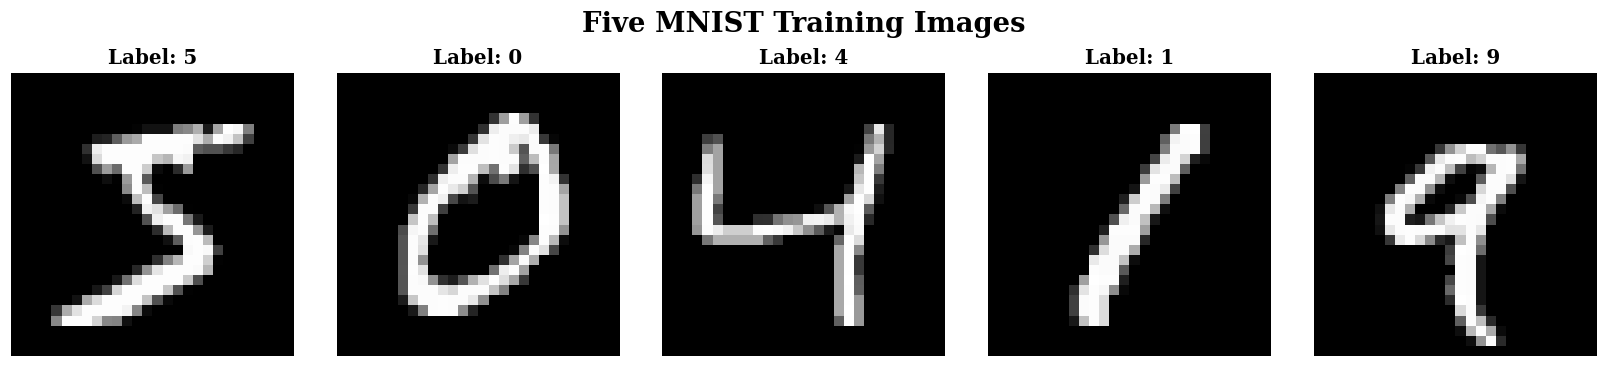

In [ ]:
# ============================================
# VISUALIZE MNIST IMAGES
# ============================================

plt.figure(figsize=(15, 3.4))

for i in range(5):

    image, label = mnist_train[i]

    plt.subplot(1, 5, i + 1)

    plt.imshow(
        image.squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Label: {label}",
        fontsize=13,
        fontweight="bold",
    )

    plt.axis("off")

plt.suptitle("Five MNIST Training Images", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()


### MNIST — Model Definition

In [ ]:
# ============================================
# CREATE MNIST FFNN
# ============================================

mnist_model = FeedForwardNN(
    input_size=28 * 28,
    hidden1_size=128,
    hidden2_size=64,
    num_classes=10
).to(device)

print(mnist_model)

FeedForwardNN(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


### MNIST — Loss Function & Optimizer

In [ ]:
# ============================================
# MNIST LOSS AND OPTIMIZER
# ============================================

mnist_criterion = nn.CrossEntropyLoss()

mnist_optimizer = torch.optim.SGD(
    mnist_model.parameters(),
    lr=LEARNING_RATE
)

### MNIST — Training

In [ ]:
# ============================================
# TRAIN MNIST FFNN
# ============================================

mnist_train_losses, mnist_train_accuracies, mnist_training_time = train_model(
    mnist_model,
    mnist_train_loader,
    mnist_criterion,
    mnist_optimizer,
    EPOCHS
)

print(
    f"\nMNIST training time: "
    f"{mnist_training_time:.2f} seconds"
)

Epoch [1/10] Loss: 0.5542 Accuracy: 85.13%
Epoch [2/10] Loss: 0.2418 Accuracy: 93.03%
Epoch [3/10] Loss: 0.1833 Accuracy: 94.75%
Epoch [4/10] Loss: 0.1477 Accuracy: 95.74%
Epoch [5/10] Loss: 0.1243 Accuracy: 96.50%
Epoch [6/10] Loss: 0.1057 Accuracy: 97.03%
Epoch [7/10] Loss: 0.0919 Accuracy: 97.38%
Epoch [8/10] Loss: 0.0807 Accuracy: 97.68%
Epoch [9/10] Loss: 0.0714 Accuracy: 97.96%
Epoch [10/10] Loss: 0.0634 Accuracy: 98.19%

MNIST training time: 148.46 seconds


### MNIST — Training Performance

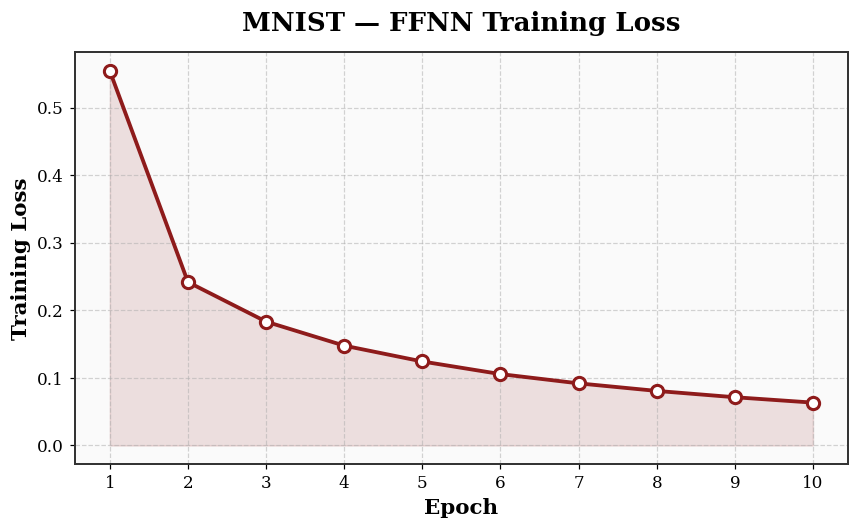

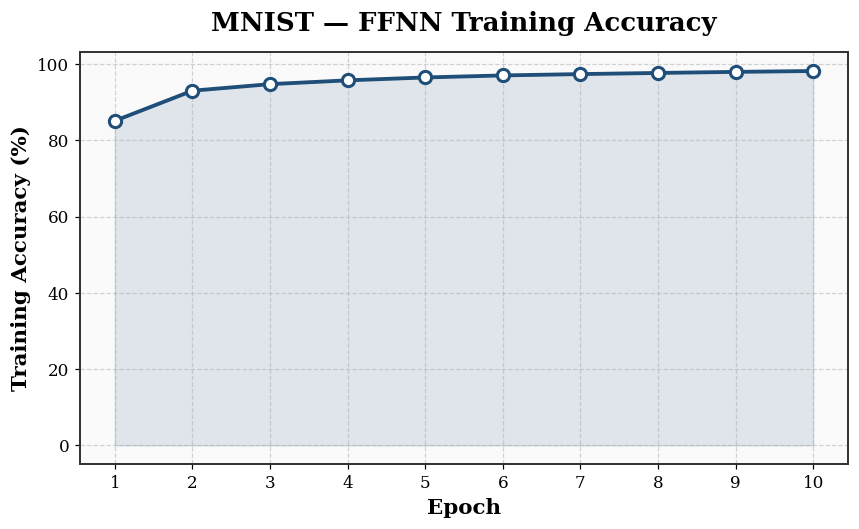

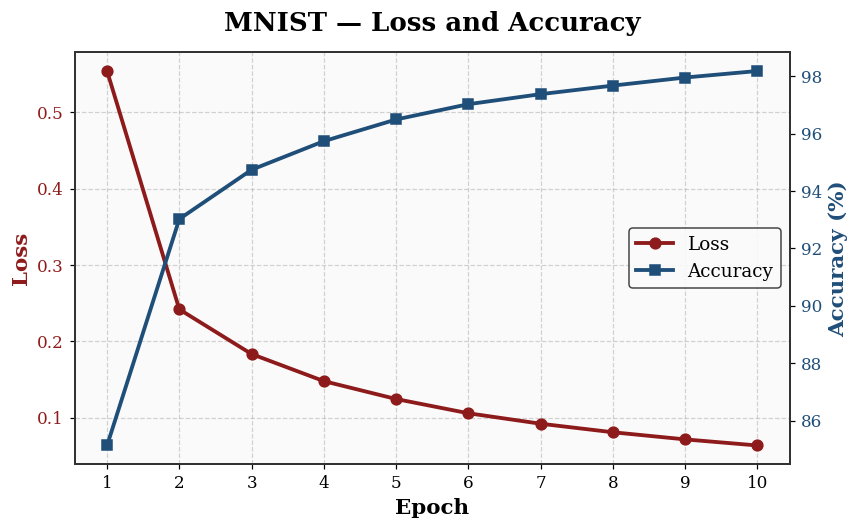

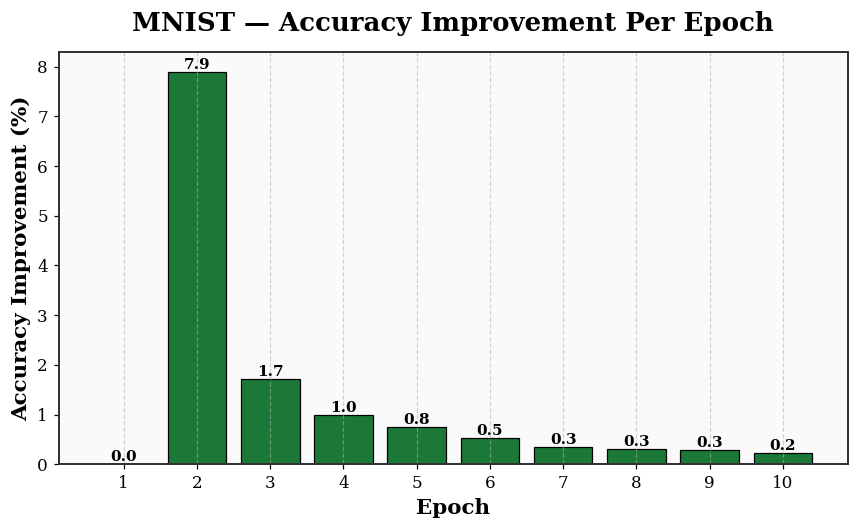

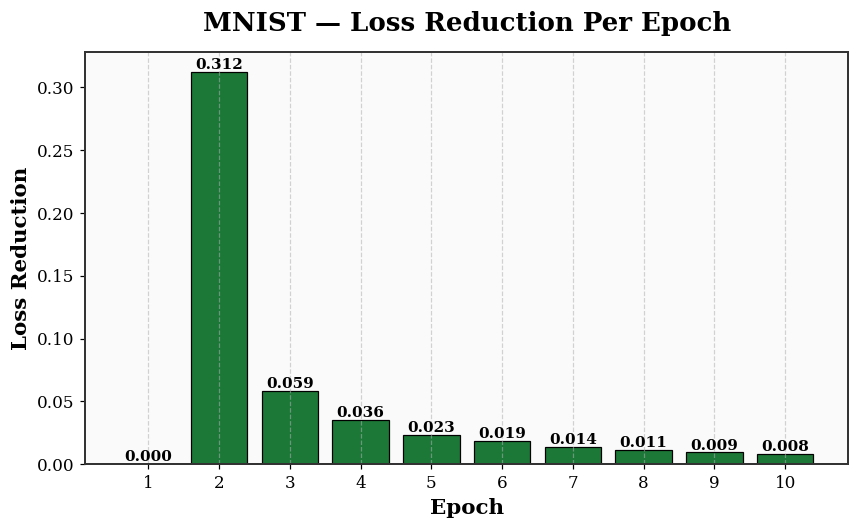

In [ ]:
# ============================================
# MNIST — TRAINING VISUALIZATION
# ============================================
# Uses the single, professionally styled plot_training_history()
# function defined in Section 5 above.

plot_training_history(
    mnist_train_losses,
    mnist_train_accuracies,
    "MNIST"
)


### MNIST — Evaluation

In [ ]:
# ============================================
# EVALUATE MNIST
# ============================================

mnist_results = evaluate_model(
    mnist_model,
    mnist_test_loader
)

print("MNIST FFNN Results")
print("-------------------------")

print(
    f"Accuracy : "
    f"{mnist_results['accuracy'] * 100:.2f}%"
)

print(
    f"Precision: "
    f"{mnist_results['precision'] * 100:.2f}%"
)

print(
    f"Recall   : "
    f"{mnist_results['recall'] * 100:.2f}%"
)

print(
    f"F1-score : "
    f"{mnist_results['f1'] * 100:.2f}%"
)

print(
    f"Training Time: "
    f"{mnist_training_time:.2f} seconds"
)

MNIST FFNN Results
-------------------------
Accuracy : 97.61%
Precision: 97.59%
Recall   : 97.59%
F1-score : 97.58%
Training Time: 148.46 seconds


### MNIST — Confusion Matrix

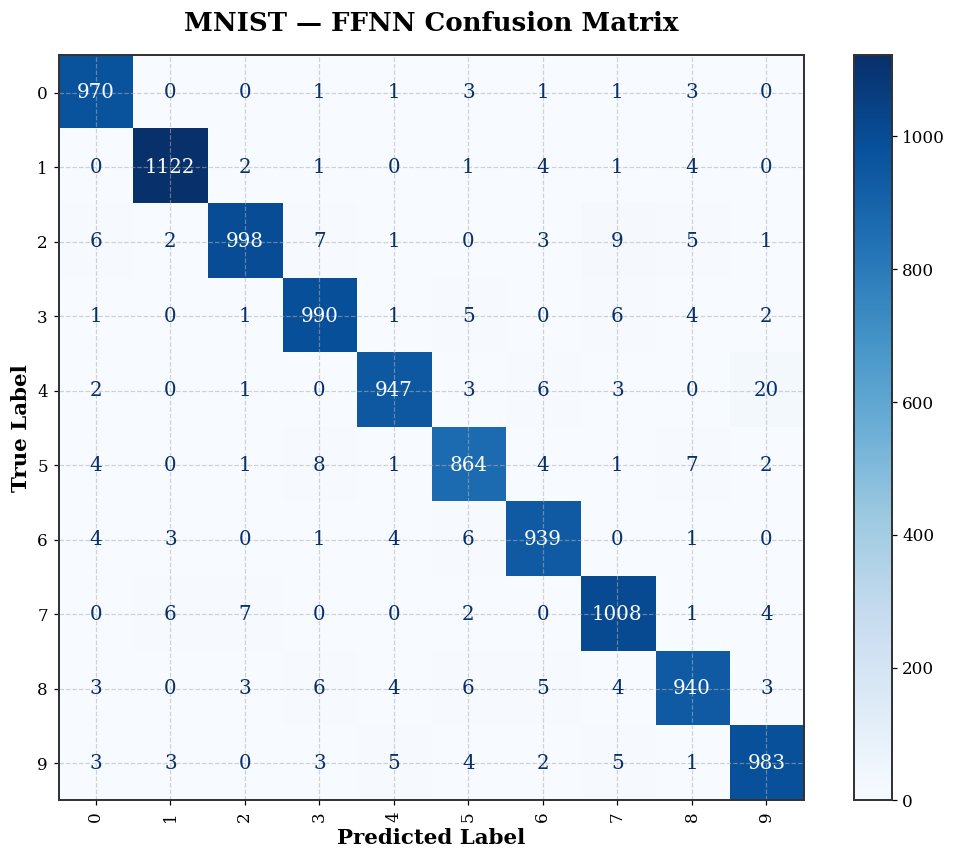

In [ ]:
plot_confusion_matrix(
    mnist_results["confusion_matrix"],
    mnist_classes,
    "MNIST"
)

### MNIST — Random Prediction

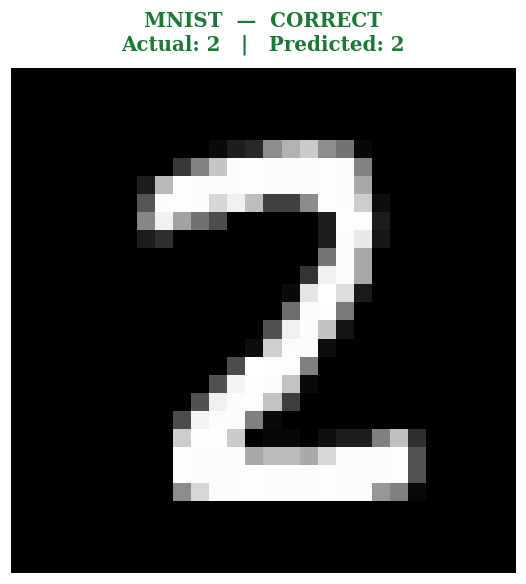

Predicted probability: 99.99%


In [ ]:
random_prediction(
    mnist_model,
    mnist_test,
    mnist_classes,
    "MNIST"
)

## Section 9 — CIFAR-10
---

In [ ]:
## 2. CIFAR-10 Dataset

# CIFAR-10 is an image classification dataset containing 10 object classes. Unlike MNIST, CIFAR-10 contains RGB colour images with three
# channels and a spatial resolution of 32 × 32 pixels.

# Since the FFNN requires a one-dimensional input vector, each CIFAR-10 image is flattened before being processed by the fully connected layers.
# The number of input features is:

# (32 times 32) times (3) = 3072

# The dataset is normalized before training.


In [ ]:
# ============================================
# CIFAR-10 DATASET
# ============================================

cifar10_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

cifar10_train = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=cifar10_transform
)

cifar10_test = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=cifar10_transform
)

cifar10_train_loader = DataLoader(
    cifar10_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

cifar10_test_loader = DataLoader(
    cifar10_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

cifar10_classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print(
    "CIFAR-10 training images:",
    len(cifar10_train)
)

print(
    "CIFAR-10 testing images:",
    len(cifar10_test)
)

100%|██████████| 170M/170M [01:08<00:00, 2.48MB/s]


CIFAR-10 training images: 50000
CIFAR-10 testing images: 10000


### CIFAR-10 — Sample Images

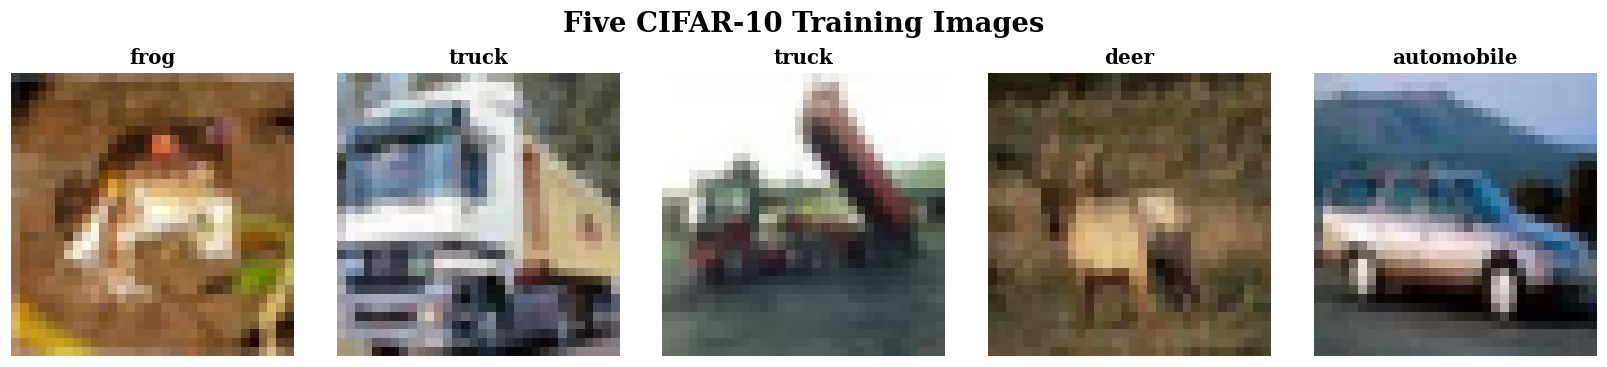

In [ ]:
# ============================================
# VISUALIZE CIFAR-10 IMAGES
# ============================================

plt.figure(figsize=(15, 3.4))

for i in range(5):

    image, label = cifar10_train[i]

    # Undo normalization for visualization
    mean = torch.tensor(
        [0.4914, 0.4822, 0.4465]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.2470, 0.2435, 0.2616]
    ).view(3, 1, 1)

    image_display = image * std + mean

    image_display = torch.clamp(
        image_display,
        0,
        1
    )

    plt.subplot(1, 5, i + 1)

    plt.imshow(
        image_display.permute(1, 2, 0)
    )

    plt.title(
        f"{cifar10_classes[label]}",
        fontsize=13,
        fontweight="bold",
    )

    plt.axis("off")

plt.suptitle("Five CIFAR-10 Training Images", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()


### CIFAR-10 — Model Definition

In [ ]:
# ============================================
# CREATE CIFAR-10 FFNN
# ============================================

cifar10_model = FeedForwardNN(
    input_size=32 * 32 * 3,
    hidden1_size=256,
    hidden2_size=128,
    num_classes=10
).to(device)

print(cifar10_model)

FeedForwardNN(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


### CIFAR-10 — Loss Function & Optimizer

In [ ]:
# ============================================
# CIFAR-10 LOSS AND OPTIMIZER
# ============================================

cifar10_criterion = nn.CrossEntropyLoss()

cifar10_optimizer = torch.optim.SGD(
    cifar10_model.parameters(),
    lr=LEARNING_RATE
)

### CIFAR-10 — Training

In [ ]:
# ============================================
# TRAIN CIFAR-10 FFNN
# ============================================

cifar10_train_losses, cifar10_train_accuracies, cifar10_training_time = train_model(
    cifar10_model,
    cifar10_train_loader,
    cifar10_criterion,
    cifar10_optimizer,
    EPOCHS
)

print(
    f"\nCIFAR-10 training time: "
    f"{cifar10_training_time:.2f} seconds"
)

Epoch [1/10] Loss: 1.7809 Accuracy: 37.16%
Epoch [2/10] Loss: 1.5267 Accuracy: 46.21%
Epoch [3/10] Loss: 1.4199 Accuracy: 50.10%
Epoch [4/10] Loss: 1.3428 Accuracy: 52.94%
Epoch [5/10] Loss: 1.2788 Accuracy: 55.26%
Epoch [6/10] Loss: 1.2205 Accuracy: 57.29%
Epoch [7/10] Loss: 1.1694 Accuracy: 59.09%
Epoch [8/10] Loss: 1.1218 Accuracy: 60.90%
Epoch [9/10] Loss: 1.0789 Accuracy: 62.25%
Epoch [10/10] Loss: 1.0373 Accuracy: 63.79%

CIFAR-10 training time: 141.55 seconds


### CIFAR-10 — Training Performance

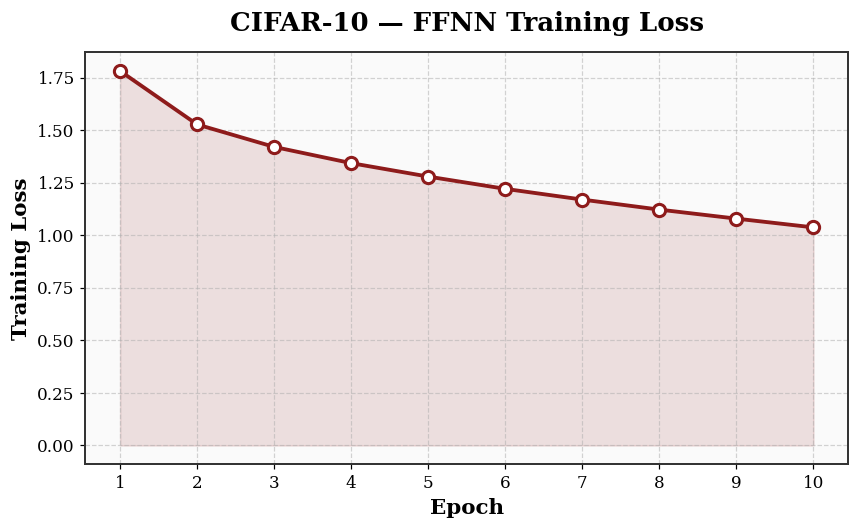

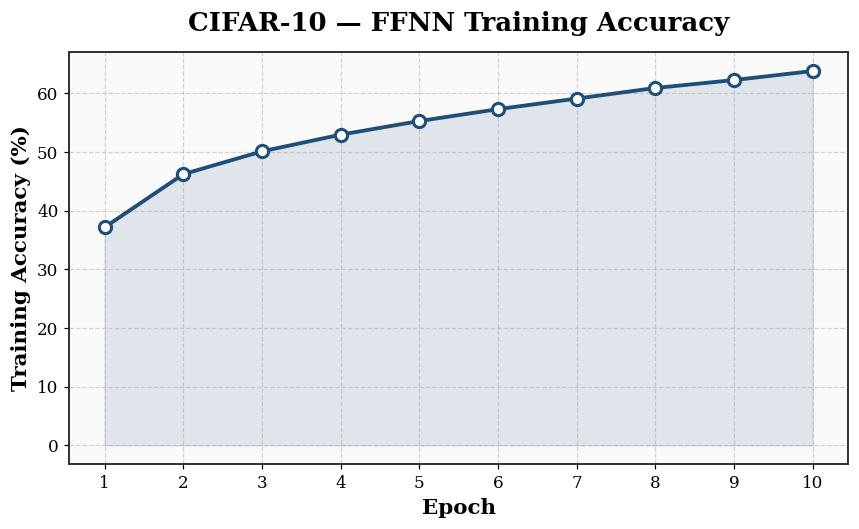

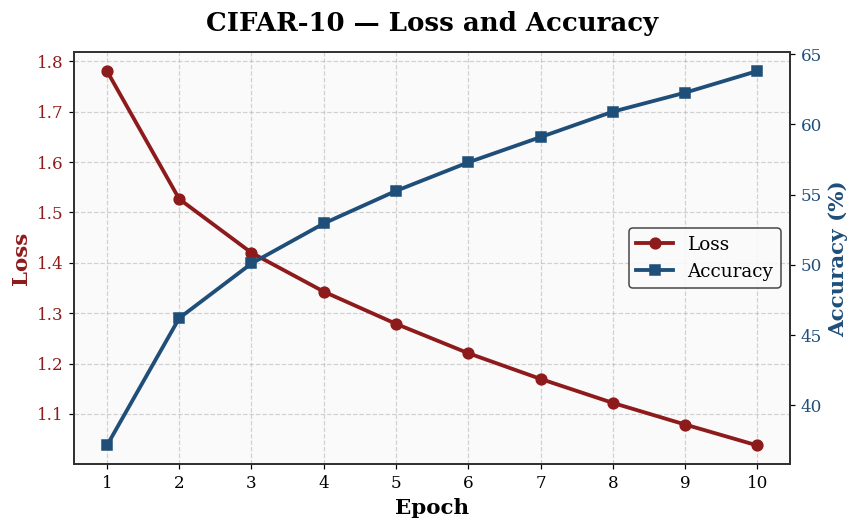

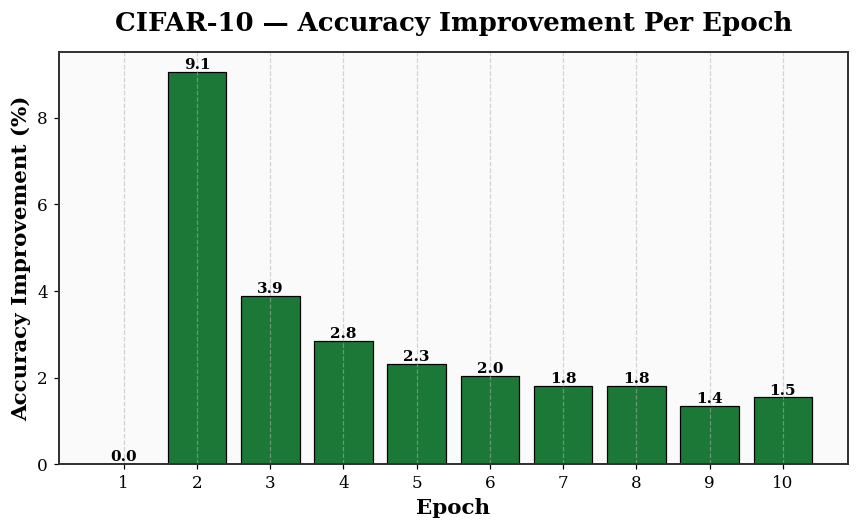

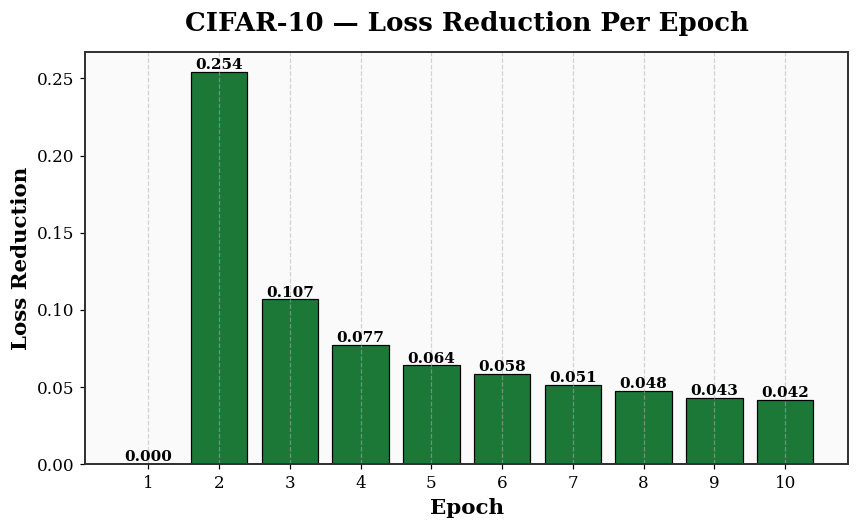

In [ ]:
plot_training_history(
    cifar10_train_losses,
    cifar10_train_accuracies,
    "CIFAR-10"
)

### CIFAR-10 — Evaluation

In [ ]:
# ============================================
# EVALUATE CIFAR-10
# ============================================

cifar10_results = evaluate_model(
    cifar10_model,
    cifar10_test_loader
)

print("CIFAR-10 FFNN Results")
print("-------------------------")

print(
    f"Accuracy : "
    f"{cifar10_results['accuracy'] * 100:.2f}%"
)

print(
    f"Precision: "
    f"{cifar10_results['precision'] * 100:.2f}%"
)

print(
    f"Recall   : "
    f"{cifar10_results['recall'] * 100:.2f}%"
)

print(
    f"F1-score : "
    f"{cifar10_results['f1'] * 100:.2f}%"
)

print(
    f"Training Time: "
    f"{cifar10_training_time:.2f} seconds"
)

CIFAR-10 FFNN Results
-------------------------
Accuracy : 52.22%
Precision: 52.09%
Recall   : 52.22%
F1-score : 51.98%
Training Time: 141.55 seconds


### CIFAR-10 — Confusion Matrix

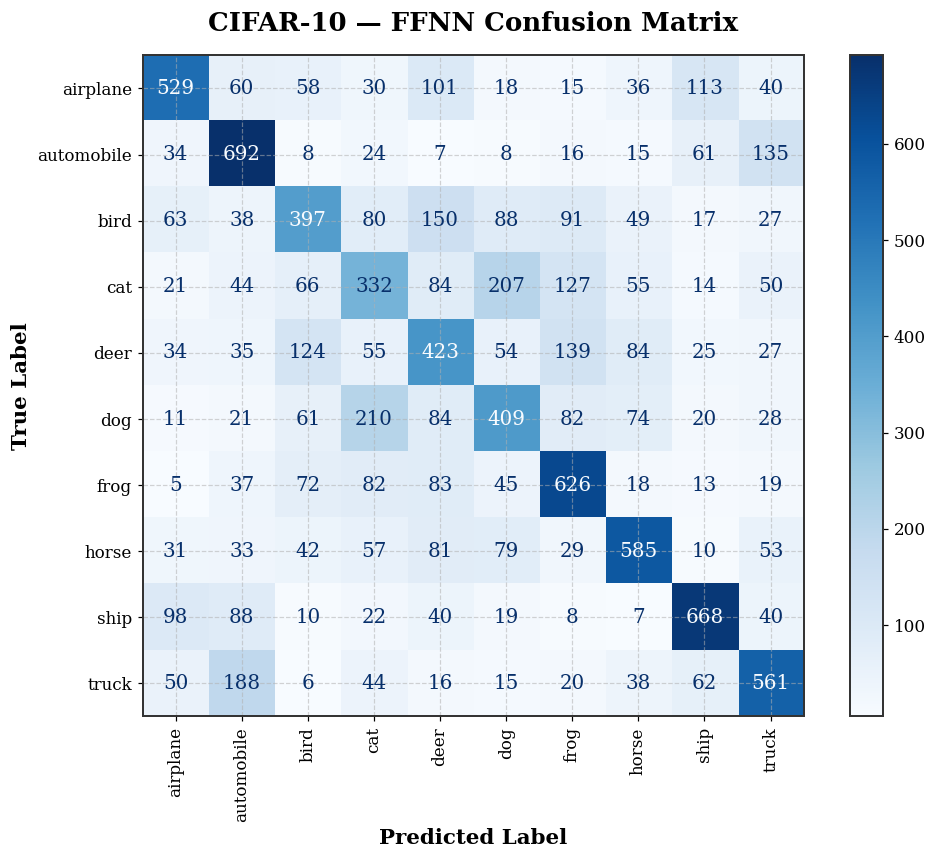

In [ ]:
plot_confusion_matrix(
    cifar10_results["confusion_matrix"],
    cifar10_classes,
    "CIFAR-10"
)

### CIFAR-10 — Random Prediction

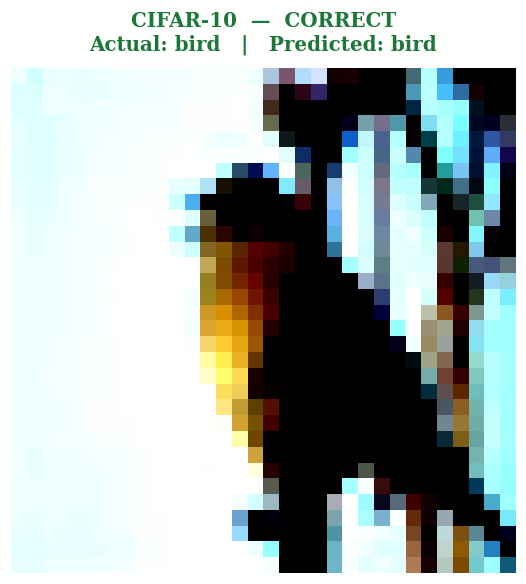

Predicted probability: 46.71%


In [ ]:
random_prediction(
    cifar10_model,
    cifar10_test,
    cifar10_classes,
    "CIFAR-10"
)

## Section 10 — CIFAR-100
---

In [ ]:
# 3. CIFAR-100 Dataset

# CIFAR-100 is a more challenging image classification dataset containing 100 object classes. Similar to CIFAR-10, each image is an RGB image
# with three channels and a resolution of 32 × 32 pixels.

# For the FFNN, each image is flattened into:

# [ (32 times 32) times (3) = 3072]

# input features. The output layer contains 100 neurons, corresponding to the 100 CIFAR-100 classes. The same training configuration is
# maintained to allow comparison with MNIST and CIFAR-10.

In [ ]:
# ============================================
# CIFAR-100 DATASET
# ============================================

cifar100_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5071, 0.4867, 0.4408),
        (0.2675, 0.2565, 0.2761)
    )
])

cifar100_train = datasets.CIFAR100(
    root="./data",
    train=True,
    download=True,
    transform=cifar100_transform
)

cifar100_test = datasets.CIFAR100(
    root="./data",
    train=False,
    download=True,
    transform=cifar100_transform
)

cifar100_train_loader = DataLoader(
    cifar100_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

cifar100_test_loader = DataLoader(
    cifar100_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

cifar100_classes = cifar100_train.classes

print(
    "CIFAR-100 training images:",
    len(cifar100_train)
)

print(
    "CIFAR-100 testing images:",
    len(cifar100_test)
)

print(
    "Number of classes:",
    len(cifar100_classes)
)

100%|██████████| 169M/169M [00:04<00:00, 39.3MB/s]


CIFAR-100 training images: 50000
CIFAR-100 testing images: 10000
Number of classes: 100


### CIFAR-100 — Sample Images

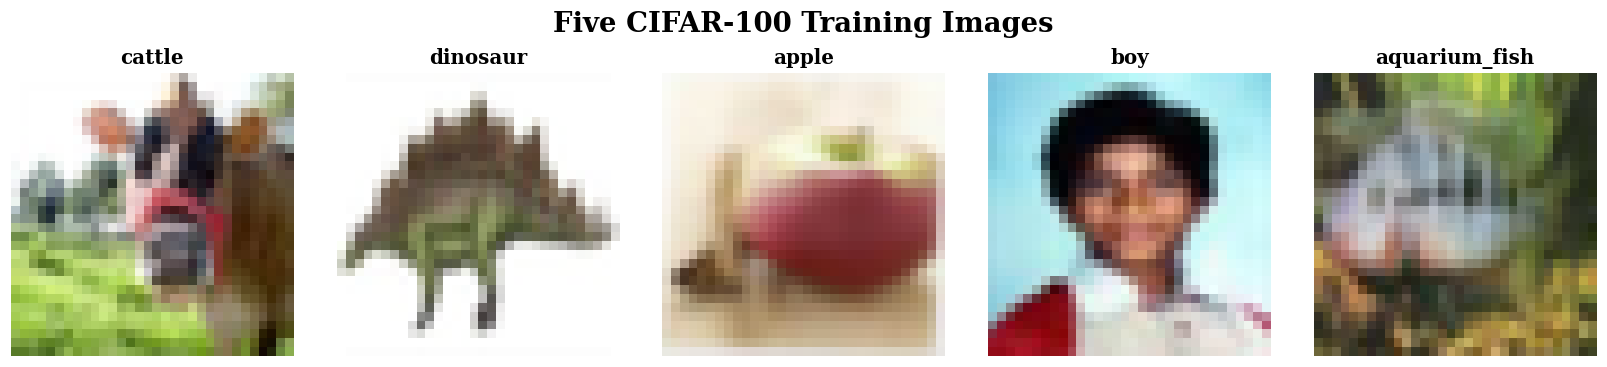

In [ ]:
# ============================================
# VISUALIZE CIFAR-100 IMAGES
# ============================================

plt.figure(figsize=(15, 3.4))

for i in range(5):

    image, label = cifar100_train[i]

    # Undo normalization for visualization
    mean = torch.tensor(
        [0.5071, 0.4867, 0.4408]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.2675, 0.2565, 0.2761]
    ).view(3, 1, 1)

    image_display = image * std + mean

    image_display = torch.clamp(
        image_display,
        0,
        1
    )

    plt.subplot(1, 5, i + 1)

    plt.imshow(
        image_display.permute(1, 2, 0)
    )

    plt.title(
        f"{cifar100_classes[label]}",
        fontsize=13,
        fontweight="bold",
    )

    plt.axis("off")

plt.suptitle("Five CIFAR-100 Training Images", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()


### CIFAR-100 — Model Definition

In [ ]:
# ============================================
# CREATE CIFAR-100 FFNN
# ============================================

cifar100_model = FeedForwardNN(
    input_size=32 * 32 * 3,
    hidden1_size=256,
    hidden2_size=128,
    num_classes=100
).to(device)

print(cifar100_model)

FeedForwardNN(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=100, bias=True)
  )
)


### CIFAR-100 — Loss Function & Optimizer

In [ ]:
# ============================================
# CIFAR-100 LOSS AND OPTIMIZER
# ============================================

cifar100_criterion = nn.CrossEntropyLoss()

cifar100_optimizer = torch.optim.SGD(
    cifar100_model.parameters(),
    lr=LEARNING_RATE
)

### CIFAR-100 — Training

In [ ]:
# ============================================
# TRAIN CIFAR-100 FFNN
# ============================================

cifar100_train_losses, cifar100_train_accuracies, cifar100_training_time = train_model(
    cifar100_model,
    cifar100_train_loader,
    cifar100_criterion,
    cifar100_optimizer,
    EPOCHS
)

print(
    f"\nCIFAR-100 training time: "
    f"{cifar100_training_time:.2f} seconds"
)

Epoch [1/10] Loss: 4.1437 Accuracy: 7.94%
Epoch [2/10] Loss: 3.6761 Accuracy: 14.58%
Epoch [3/10] Loss: 3.4898 Accuracy: 17.80%
Epoch [4/10] Loss: 3.3614 Accuracy: 20.18%
Epoch [5/10] Loss: 3.2546 Accuracy: 22.23%
Epoch [6/10] Loss: 3.1609 Accuracy: 24.21%
Epoch [7/10] Loss: 3.0759 Accuracy: 25.60%
Epoch [8/10] Loss: 2.9995 Accuracy: 26.91%
Epoch [9/10] Loss: 2.9275 Accuracy: 28.31%
Epoch [10/10] Loss: 2.8585 Accuracy: 29.90%

CIFAR-100 training time: 146.34 seconds


### CIFAR-100 — Training Performance

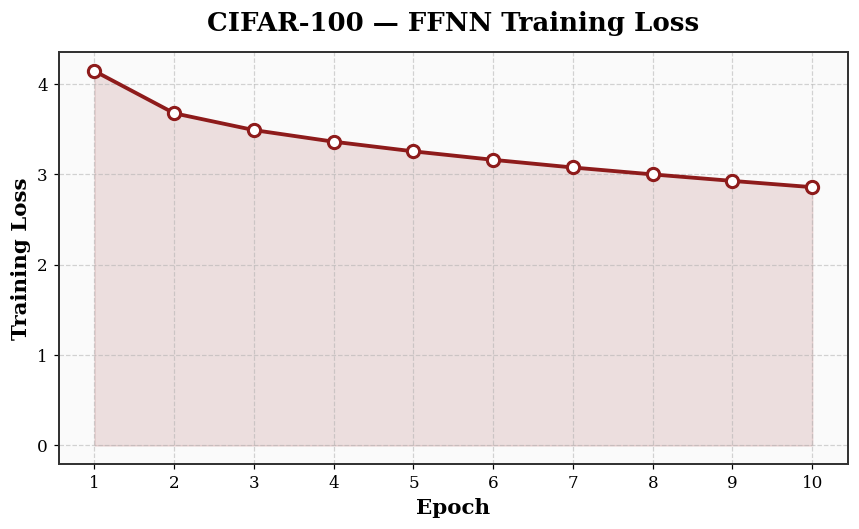

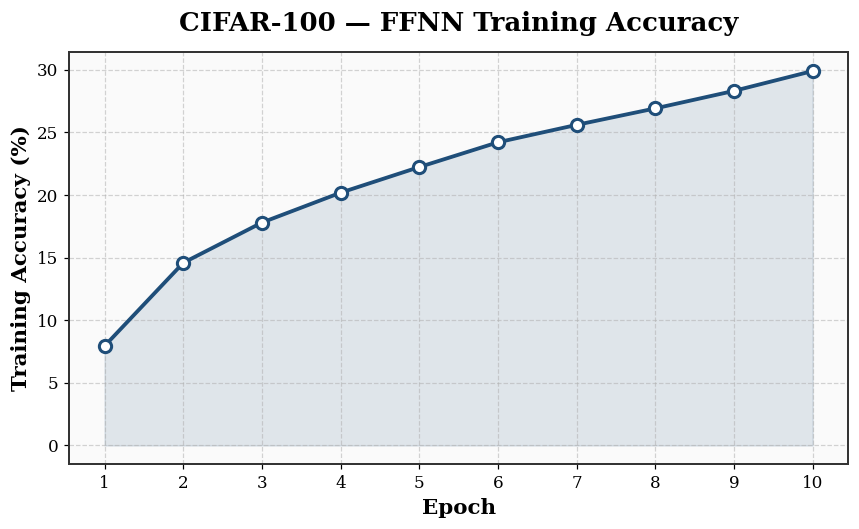

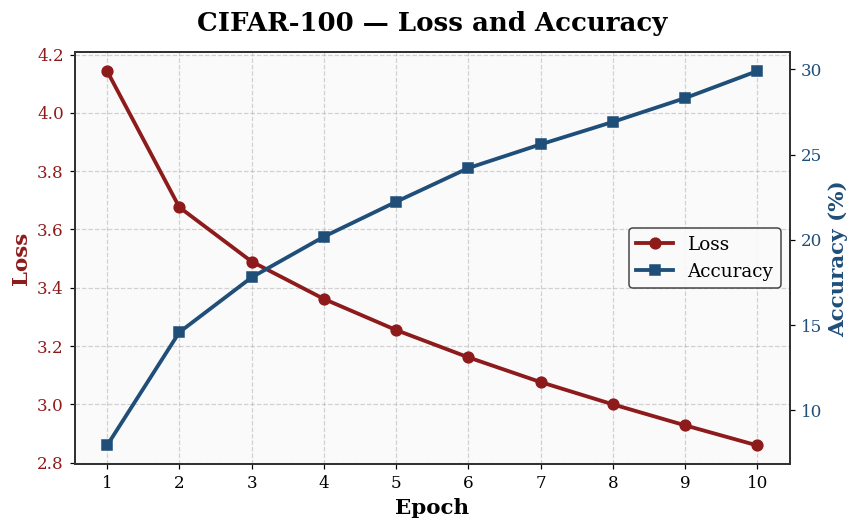

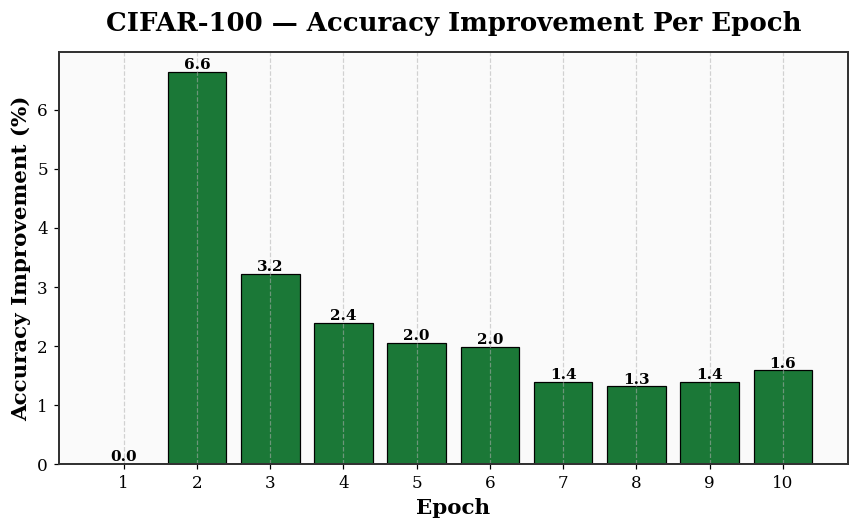

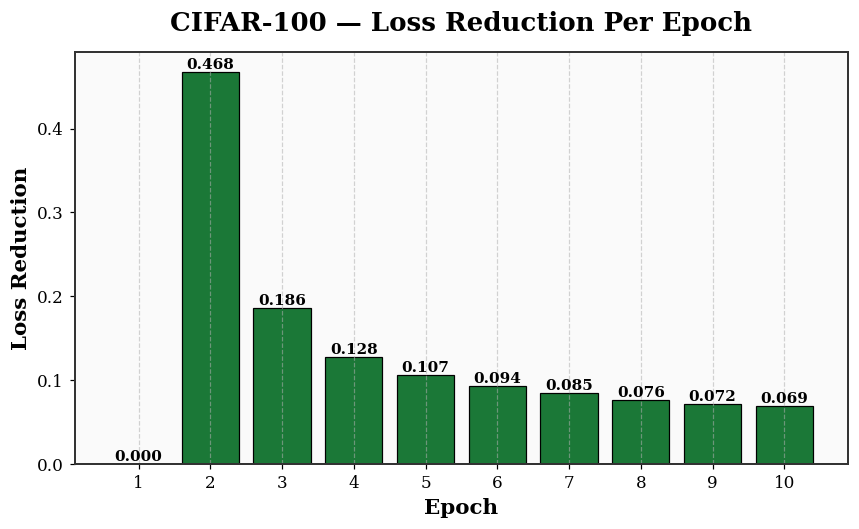

In [ ]:
plot_training_history(
    cifar100_train_losses,
    cifar100_train_accuracies,
    "CIFAR-100"
)

### CIFAR-100 — Evaluation

In [ ]:
# ============================================
# EVALUATE CIFAR-100
# ============================================

cifar100_results = evaluate_model(
    cifar100_model,
    cifar100_test_loader
)

print("CIFAR-100 FFNN Results")
print("-------------------------")

print(
    f"Accuracy : "
    f"{cifar100_results['accuracy'] * 100:.2f}%"
)

print(
    f"Precision: "
    f"{cifar100_results['precision'] * 100:.2f}%"
)

print(
    f"Recall   : "
    f"{cifar100_results['recall'] * 100:.2f}%"
)

print(
    f"F1-score : "
    f"{cifar100_results['f1'] * 100:.2f}%"
)

print(
    f"Training Time: "
    f"{cifar100_training_time:.2f} seconds"
)

CIFAR-100 FFNN Results
-------------------------
Accuracy : 24.03%
Precision: 24.38%
Recall   : 24.03%
F1-score : 22.71%
Training Time: 146.34 seconds


### CIFAR-100 — Confusion Matrix

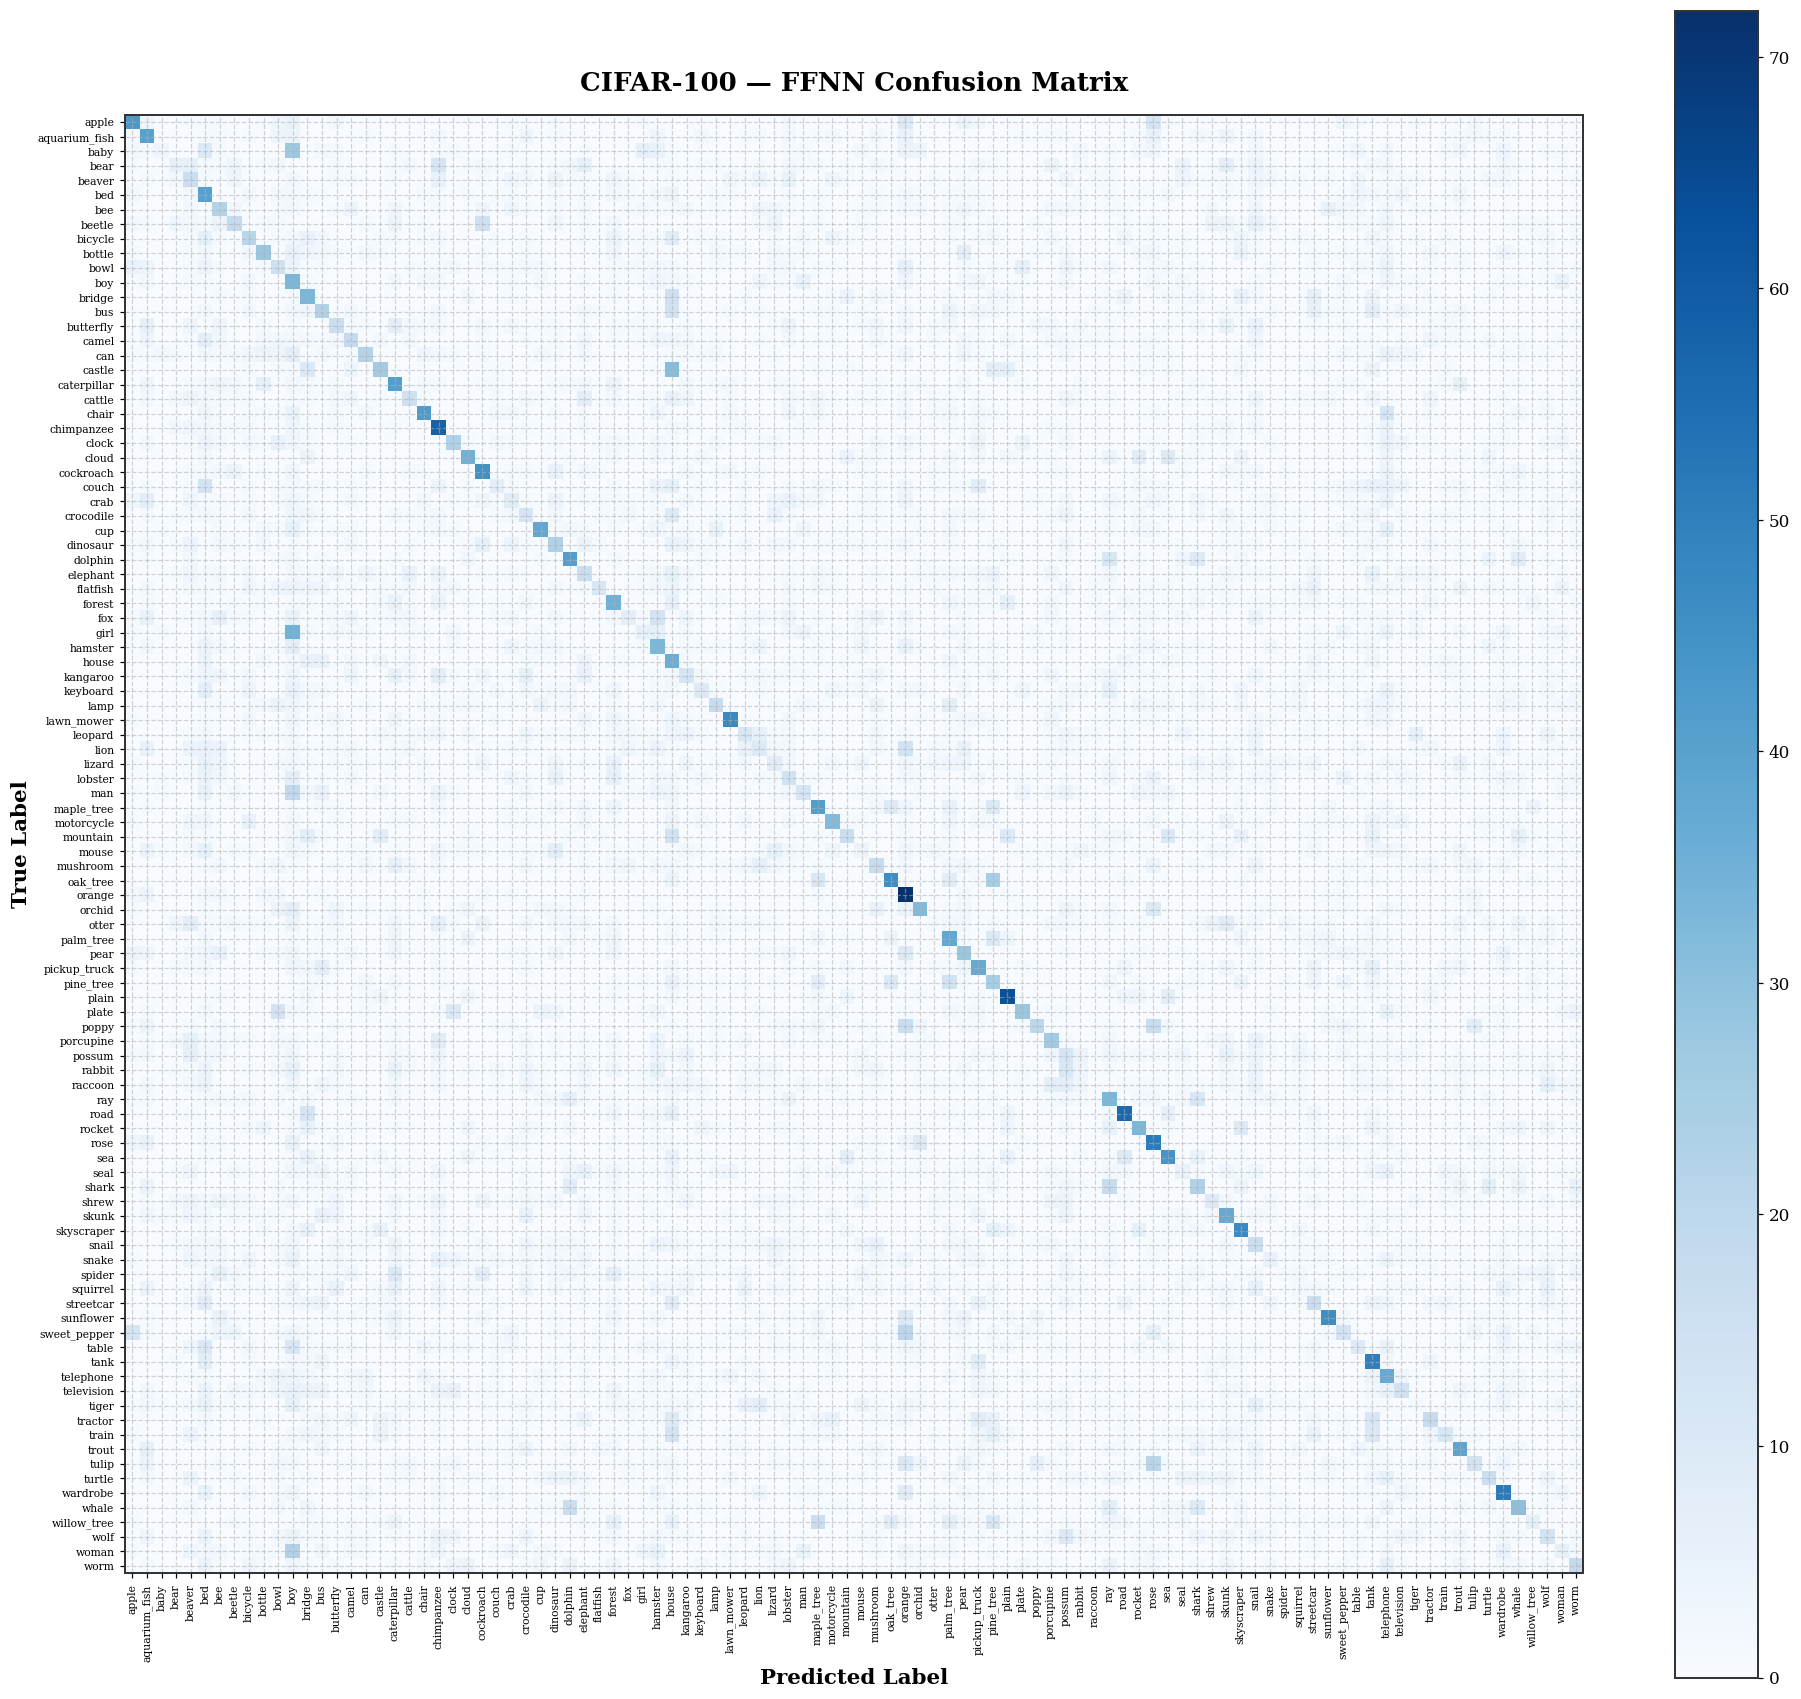

In [ ]:
plot_confusion_matrix(
    cifar100_results["confusion_matrix"],
    cifar100_classes,
    "CIFAR-100"
)

### CIFAR-100 — Random Prediction

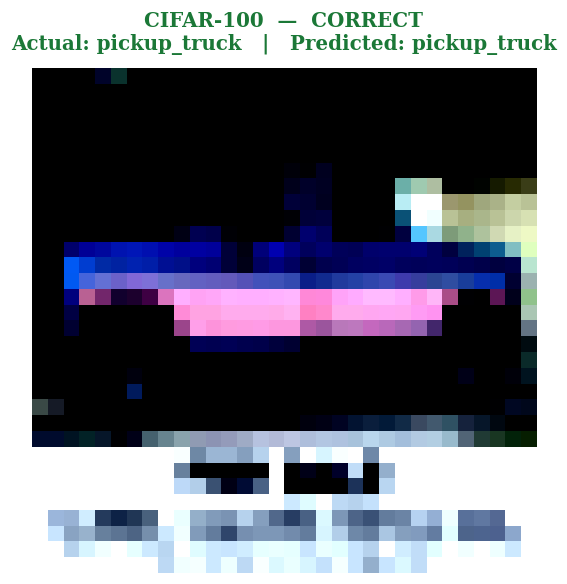

Predicted probability: 70.22%


In [ ]:
random_prediction(
    cifar100_model,
    cifar100_test,
    cifar100_classes,
    "CIFAR-100"
)

## Section 11 — Results Table

In [ ]:
# ============================================
# QUESTION 1 - RESULTS TABLE
# ============================================

q1_results = {
    "Dataset": [
        "MNIST",
        "CIFAR-10",
        "CIFAR-100"
    ],

    "Accuracy (%)": [
        mnist_results["accuracy"] * 100,
        cifar10_results["accuracy"] * 100,
        cifar100_results["accuracy"] * 100
    ],

    "Precision (%)": [
        mnist_results["precision"] * 100,
        cifar10_results["precision"] * 100,
        cifar100_results["precision"] * 100
    ],

    "Recall (%)": [
        mnist_results["recall"] * 100,
        cifar10_results["recall"] * 100,
        cifar100_results["recall"] * 100
    ],

    "F1-score (%)": [
        mnist_results["f1"] * 100,
        cifar10_results["f1"] * 100,
        cifar100_results["f1"] * 100
    ],

    "Training Time (s)": [
        mnist_training_time,
        cifar10_training_time,
        cifar100_training_time
    ]
}

import pandas as pd

q1_results_df = pd.DataFrame(q1_results)

q1_results_df.round(2)

,Dataset,Accuracy (%),Precision (%),Recall (%),F1-score (%),Training Time (s)
0,MNIST,97.61,97.59,97.59,97.58,148.46
1,CIFAR-10,52.22,52.09,52.22,51.98,141.55
2,CIFAR-100,24.03,24.38,24.03,22.71,146.34


## Section 12 — Comparison Visualization

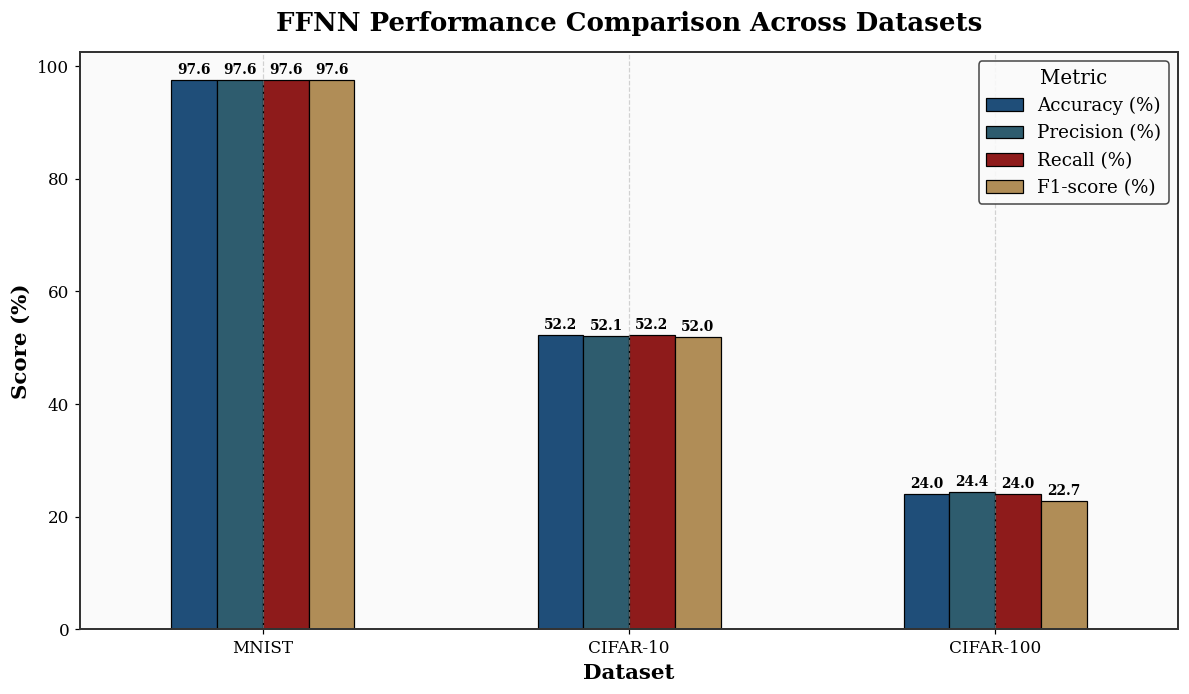

In [ ]:
# ============================================
# QUESTION 1 - METRIC COMPARISON
# ============================================

metrics = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-score (%)"
]

comparison_colors = ["#1F4E79", "#2E5C6E", "#8E1B1B", "#B08D57"]

ax = q1_results_df.set_index("Dataset")[metrics].plot(
    kind="bar",
    figsize=(11, 6.5),
    color=comparison_colors,
    edgecolor="black",
    linewidth=0.8,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        fontsize=9,
        fontweight="bold",
        padding=2,
    )

plt.xlabel("Dataset")
plt.ylabel("Score (%)")
plt.title(
    "FFNN Performance Comparison Across Datasets",
    fontsize=17,
    fontweight="bold",
    pad=14,
)

plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(title="Metric", loc="upper right")
plt.tight_layout()
plt.show()


## Section 13 — Initial Analysis

In [ ]:
### 13. Q1 Results Comparison and Analysis

# The feed-forward neural network was trained and evaluated on the MNIST, CIFAR-10, and CIFAR-100 datasets using stochastic gradient descent (SGD), a learning rate of 0.01,
# a batch size of 32, and 10 training epochs. The performance of the model was evaluated using accuracy, precision, recall, F1-score, and the confusion matrix.

# The results demonstrate that the model performs differently across the three datasets. MNIST generally achieves the highest classification performance because
# it contains grayscale handwritten digits with relatively simple visual patterns. CIFAR-10 is more challenging because it contains colour images of different
# objects with greater variations in shape, texture, and background. CIFAR-100 is the most challenging dataset because it contains 100 different classes,
# making the classification problem considerably more complex.

# The training curves are also useful for analysing the learning behaviour of the network. A continuous decrease in training loss together with an increase in
# training accuracy indicates that the model is successfully learning from the training data. The confusion matrices provide further insight into which classes
# are correctly classified and which classes are frequently confused with one another.

# Overall, the results show that a feed-forward neural network can perform image classification after flattening the input images into feature vectors.
# However, flattening removes the spatial structure of images, which limits the ability of the network to learn local patterns such as edges, textures, and shapes.
# This limitation becomes more noticeable on the more complex CIFAR-10 and CIFAR-100 datasets. Convolutional neural networks such as VGG16 and ResNet18 are therefore
# expected to provide better performance for image-based classification tasks.


## Section 14 — Effect of Hidden Nodes

In [ ]:
### 14. Effect of Hidden Nodes

# To investigate the effect of the number of hidden nodes on the performance of the feed-forward neural network, different hidden-layer sizes can be tested
# while keeping the remaining training settings unchanged. Increasing the number of hidden nodes increases the representational capacity of the network, allowing
# it to learn more complex patterns. However, a very large number of hidden nodes also increases the number of trainable parameters and computational cost and may increase the risk of overfitting.

# For this experiment, different combinations of hidden nodes will be compared while maintaining the same learning rate, batch size, optimizer, loss function,
#  and number of epochs. The resulting accuracy and training time will be compared to determine how the network capacity affects classification performance.


In [ ]:
# Section 14: Effect of Hidden Nodes

hidden_node_configs = [
    (64, 32),
    (128, 64),
    (256, 128)
]

hidden_node_results = []

for hidden1, hidden2 in hidden_node_configs:

    print(f"\nTesting Hidden Nodes: {hidden1} -> {hidden2}")

    model = FeedForwardNN(
        input_size=28 * 28,
        hidden1_size=hidden1,
        hidden2_size=hidden2,
        num_classes=10
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

    losses, accuracies, training_time = train_model(
        model,
        mnist_train_loader,
        criterion,
        optimizer,
        epochs=10
    )

    results = evaluate_model(model, mnist_test_loader)

    hidden_node_results.append({
        "Hidden Nodes": f"{hidden1} -> {hidden2}",
        "Accuracy (%)": results["accuracy"] * 100,
        "Precision (%)": results["precision"] * 100,
        "Recall (%)": results["recall"] * 100,
        "F1-score (%)": results["f1"] * 100,
        "Training Time (s)": training_time
    })

hidden_node_df = pd.DataFrame(hidden_node_results)

hidden_node_df.round(2)


Testing Hidden Nodes: 64 -> 32
Epoch [1/10] Loss: 0.5759 Accuracy: 84.45%
Epoch [2/10] Loss: 0.2593 Accuracy: 92.52%
Epoch [3/10] Loss: 0.1998 Accuracy: 94.23%
Epoch [4/10] Loss: 0.1619 Accuracy: 95.32%
Epoch [5/10] Loss: 0.1366 Accuracy: 96.05%
Epoch [6/10] Loss: 0.1178 Accuracy: 96.53%
Epoch [7/10] Loss: 0.1035 Accuracy: 97.02%
Epoch [8/10] Loss: 0.0923 Accuracy: 97.28%
Epoch [9/10] Loss: 0.0838 Accuracy: 97.49%
Epoch [10/10] Loss: 0.0762 Accuracy: 97.70%

Testing Hidden Nodes: 128 -> 64
Epoch [1/10] Loss: 0.5728 Accuracy: 83.79%
Epoch [2/10] Loss: 0.2451 Accuracy: 92.84%
Epoch [3/10] Loss: 0.1856 Accuracy: 94.68%
Epoch [4/10] Loss: 0.1491 Accuracy: 95.67%
Epoch [5/10] Loss: 0.1233 Accuracy: 96.41%
Epoch [6/10] Loss: 0.1045 Accuracy: 97.02%
Epoch [7/10] Loss: 0.0901 Accuracy: 97.37%
Epoch [8/10] Loss: 0.0788 Accuracy: 97.73%
Epoch [9/10] Loss: 0.0694 Accuracy: 97.98%
Epoch [10/10] Loss: 0.0615 Accuracy: 98.24%

Testing Hidden Nodes: 256 -> 128
Epoch [1/10] Loss: 0.5707 Accuracy: 84.

,Hidden Nodes,Accuracy (%),Precision (%),Recall (%),F1-score (%),Training Time (s)
0,64 -> 32,97.16,97.15,97.13,97.14,155.15
1,128 -> 64,97.36,97.37,97.34,97.35,153.89
2,256 -> 128,97.58,97.57,97.56,97.56,151.38


## Section 15 — Hidden Node Comparison Graph

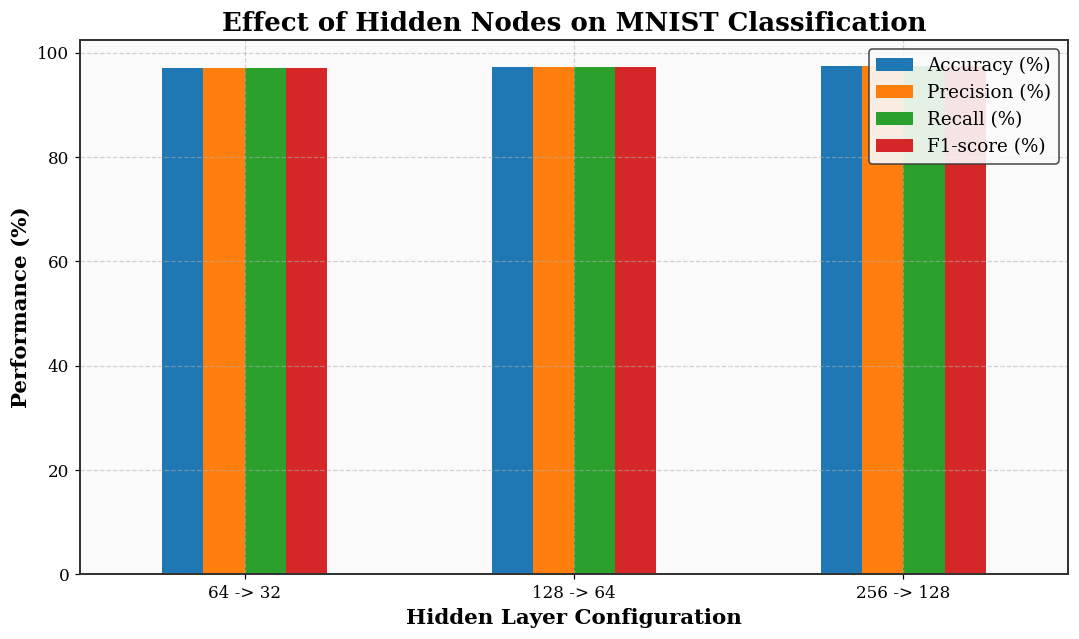

In [ ]:
# Compare the effect of hidden nodes

metrics = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-score (%)"
]

hidden_node_df.set_index("Hidden Nodes")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Effect of Hidden Nodes on MNIST Classification")
plt.xlabel("Hidden Layer Configuration")
plt.ylabel("Performance (%)")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

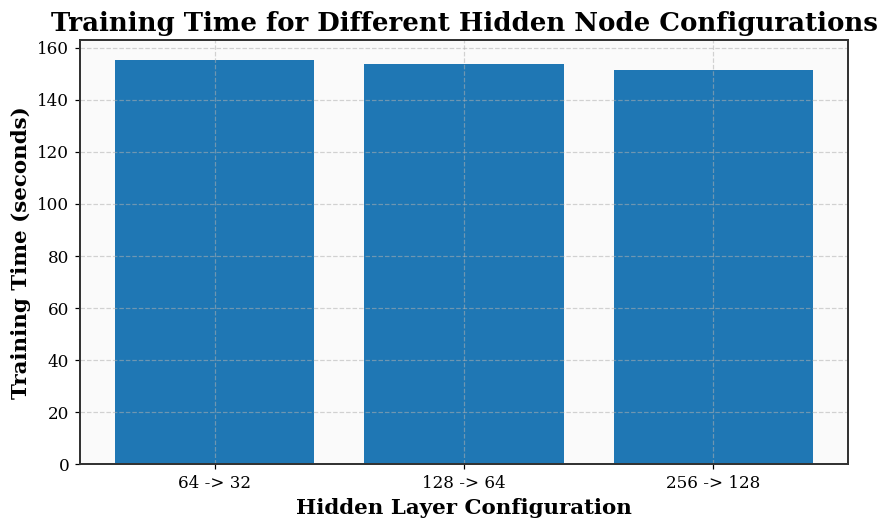

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    hidden_node_df["Hidden Nodes"],
    hidden_node_df["Training Time (s)"]
)

plt.title("Training Time for Different Hidden Node Configurations")
plt.xlabel("Hidden Layer Configuration")
plt.ylabel("Training Time (seconds)")
plt.tight_layout()
plt.show()

## Section 16 — Effect of Hidden Layers

In [ ]:
# 16. Effect of Hidden Layers

# The effect of network depth can also be investigated by comparing feed-forward neural networks with different numbers of hidden layers.
# Increasing the number of hidden layers allows the network to learn hierarchical representations, where earlier layers learn simpler features and
# later layers combine these features into more complex representations.

# However, increasing depth also increases the number of trainable parameters and can make optimisation more difficult.
# Therefore, the effect of additional hidden layers should be evaluated using the same dataset and training configuration

In [ ]:
class FlexibleFeedForwardNN(nn.Module):
    def __init__(self, input_size, hidden_layers, num_classes):
        super(FlexibleFeedForwardNN, self).__init__()

        layers = [nn.Flatten()]

        previous_size = input_size

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(previous_size, hidden_size))
            layers.append(nn.ReLU())
            previous_size = hidden_size

        layers.append(nn.Linear(previous_size, num_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [ ]:
# Section 16: Effect of Hidden Layers

layer_configs = [
    [128],              # 1 hidden layer
    [128, 64],          # 2 hidden layers
    [128, 64, 32]       # 3 hidden layers
]

layer_results = []

for config in layer_configs:

    print(f"\nTesting Hidden Layers: {config}")

    model = FlexibleFeedForwardNN(
        input_size=28 * 28,
        hidden_layers=config,
        num_classes=10
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

    losses, accuracies, training_time = train_model(
        model,
        mnist_train_loader,
        criterion,
        optimizer,
        epochs=10
    )

    results = evaluate_model(model, mnist_test_loader)

    layer_results.append({
        "Hidden Layers": len(config),
        "Architecture": str(config),
        "Accuracy (%)": results["accuracy"] * 100,
        "Precision (%)": results["precision"] * 100,
        "Recall (%)": results["recall"] * 100,
        "F1-score (%)": results["f1"] * 100,
        "Training Time (s)": training_time
    })

layer_df = pd.DataFrame(layer_results)

layer_df.round(2)


Testing Hidden Layers: [128]
Epoch [1/10] Loss: 0.4464 Accuracy: 88.23%
Epoch [2/10] Loss: 0.2425 Accuracy: 93.03%
Epoch [3/10] Loss: 0.1929 Accuracy: 94.52%
Epoch [4/10] Loss: 0.1607 Accuracy: 95.44%
Epoch [5/10] Loss: 0.1381 Accuracy: 96.08%
Epoch [6/10] Loss: 0.1210 Accuracy: 96.56%
Epoch [7/10] Loss: 0.1076 Accuracy: 96.98%
Epoch [8/10] Loss: 0.0969 Accuracy: 97.28%
Epoch [9/10] Loss: 0.0874 Accuracy: 97.52%
Epoch [10/10] Loss: 0.0802 Accuracy: 97.75%

Testing Hidden Layers: [128, 64]
Epoch [1/10] Loss: 0.5732 Accuracy: 84.20%
Epoch [2/10] Loss: 0.2478 Accuracy: 92.75%
Epoch [3/10] Loss: 0.1867 Accuracy: 94.58%
Epoch [4/10] Loss: 0.1490 Accuracy: 95.62%
Epoch [5/10] Loss: 0.1231 Accuracy: 96.44%
Epoch [6/10] Loss: 0.1050 Accuracy: 96.93%
Epoch [7/10] Loss: 0.0908 Accuracy: 97.40%
Epoch [8/10] Loss: 0.0800 Accuracy: 97.70%
Epoch [9/10] Loss: 0.0706 Accuracy: 97.96%
Epoch [10/10] Loss: 0.0629 Accuracy: 98.21%

Testing Hidden Layers: [128, 64, 32]
Epoch [1/10] Loss: 0.8415 Accuracy: 

,Hidden Layers,Architecture,Accuracy (%),Precision (%),Recall (%),F1-score (%),Training Time (s)
0,1,[128],97.34,97.34,97.31,97.32,145.12
1,2,"[128, 64]",97.48,97.48,97.45,97.46,156.27
2,3,"[128, 64, 32]",97.53,97.51,97.51,97.51,156.47


## Section 17 — Hidden Layer Comparison Graph

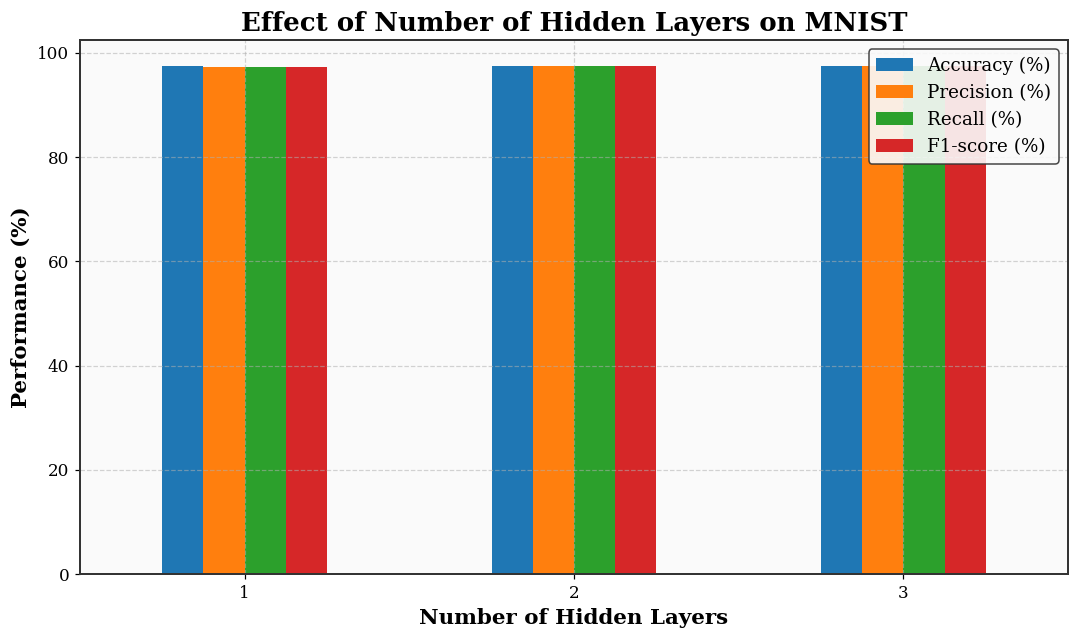

In [ ]:
metrics = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-score (%)"
]

layer_df.set_index("Hidden Layers")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Effect of Number of Hidden Layers on MNIST")
plt.xlabel("Number of Hidden Layers")
plt.ylabel("Performance (%)")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

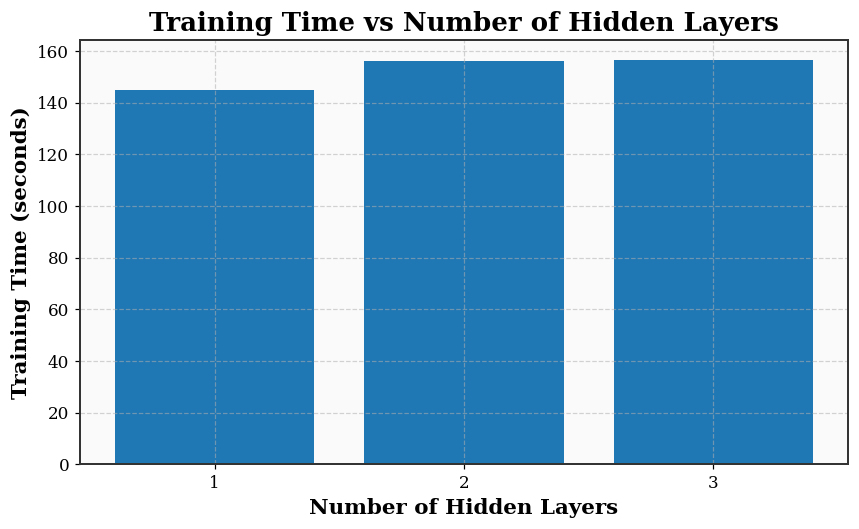

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    layer_df["Hidden Layers"].astype(str),
    layer_df["Training Time (s)"]
)

plt.title("Training Time vs Number of Hidden Layers")
plt.xlabel("Number of Hidden Layers")
plt.ylabel("Training Time (seconds)")
plt.tight_layout()
plt.show()

In [ ]:
hidden_node_df.round(2)

,Hidden Nodes,Accuracy (%),Precision (%),Recall (%),F1-score (%),Training Time (s)
0,64 -> 32,97.16,97.15,97.13,97.14,155.15
1,128 -> 64,97.36,97.37,97.34,97.35,153.89
2,256 -> 128,97.58,97.57,97.56,97.56,151.38


In [ ]:
layer_df.round(2)

,Hidden Layers,Architecture,Accuracy (%),Precision (%),Recall (%),F1-score (%),Training Time (s)
0,1,[128],97.34,97.34,97.31,97.32,145.12
1,2,"[128, 64]",97.48,97.48,97.45,97.46,156.27
2,3,"[128, 64, 32]",97.53,97.51,97.51,97.51,156.47


In [ ]:
### 18. Analysis of Hidden Nodes and Hidden Layers

# The experiments were conducted on the MNIST dataset to investigate how the number of hidden nodes and hidden layers affects the performance of the feed-forward neural network.
# The same learning rate of 0.01, batch size of 32, SGD optimizer, cross-entropy loss, and 10 training epochs were maintained for a fair comparison.

#### Effect of Hidden Nodes

# Three hidden-node configurations were evaluated: 64→32, 128→64, and 256→128. The results show a gradual improvement in classification performance as
# the number of hidden nodes increased. The accuracy increased from 97.16% for the 64→32 configuration to 97.36% for 128→64 and 97.58% for 256→128.
#  A similar trend was observed for precision, recall, and F1-score.

# The F1-score increased from 97.14% to 97.35% and finally to 97.56%, indicating that increasing the hidden-node capacity allowed the network to
# learn more representative features from the MNIST images. The largest configuration, 256→128, achieved the best overall classification performance.

# Interestingly, the measured training time did not increase with the number of hidden nodes in this experiment. The training times were 155.15 seconds,
# 153.89 seconds, and 151.38 seconds for 64→32, 128→64, and 256→128 respectively. This small variation is likely related to execution and hardware conditions
# rather than indicating that larger networks are inherently faster. Therefore, training time should be interpreted cautiously, while the performance metrics provide the main basis for comparison.

# Overall, the results suggest that increasing the number of hidden nodes improved the model's ability to represent the MNIST classification problem within the
# tested range. However, excessively increasing the number of nodes could increase the number of parameters, computational requirements, and potential risk of overfitting.

#### Effect of Hidden Layers

# The effect of network depth was evaluated using one, two, and three hidden layers. The one-hidden-layer architecture [128] achieved an accuracy of 97.34%,
# while the two-hidden-layer architecture [128, 64] achieved 97.48%. The three-hidden-layer architecture [128, 64, 32] achieved the highest accuracy of 97.53%.

# The precision, recall, and F1-score followed a similar pattern. The F1-score increased from 97.32% with one hidden layer to 97.46% with two hidden layers and
# 97.51% with three hidden layers. This indicates that adding hidden layers provided a small improvement in the network's ability to learn hierarchical representations.

# However, the improvement became relatively small as additional layers were introduced. The accuracy increased by only 0.05 percentage points from two hidden layers
# to three hidden layers. At the same time, training time increased from 156.27 seconds to 156.47 seconds. This demonstrates that increasing network depth does not
# necessarily produce a large performance improvement, particularly for a relatively simple dataset such as MNIST.

# Overall, the experiments demonstrate that both network width and depth can influence the performance of a feed-forward neural network. Increasing the number of
# hidden nodes produced a larger improvement within the tested configurations, while increasing the number of hidden layers produced smaller improvements.
# The best hidden-node configuration was 256→128, achieving 97.58% accuracy and a 97.56% F1-score. The best hidden-layer configuration was [128, 64, 32], achieving 97.53% accuracy and a 97.51% F1-score.

# These findings also highlight the importance of balancing model capacity and computational complexity. A larger or deeper network can learn more complex representations,
# but additional parameters should only be introduced when they provide meaningful improvements in predictive performance.
